In [1]:
## information about how to use the script
from filmscope.recon_util import (add_sample_entry, get_all_sample_names,
                                  get_ss_volume_from_dataset)
from filmscope.util import play_video, load_dictionary
from filmscope.calibration import CalibrationInfoManager
from filmscope.datasets import FSDataset
import os
from matplotlib import pyplot as plt
import numpy as np
import xarray as xr
from filmscope.config import alt_path

import torch

In [2]:
# view already saved samples 
get_all_sample_names()

['skull_with_tool', 'finger', 'knuckle_video']

In [3]:
# optional: select GPU to be used
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [4]:
# necessary information about the dataset 
path_to_data = alt_path
sample_name = "skull_tool_video" 
# this is the data's location within "path_to_data"
folder = sample_name 
image_filename = folder +"/skull_with_tool_08_12.nc"#'/finger_20240528.nc'

# frame number that will be viewed for videos
# set to -1 for images
frame_number = 0

calibration_filename = folder + '/calibration_information'
# blank images can be used to remove illumination artifacts
# set to None if this was not acquired
blank_filename = folder + "/skull_tool_blank_20240812_094237_382.nc" 
bf = blank_filename 
if bf is not None:
    bf = path_to_data + '/' + bf

In [5]:
print(path_to_data)
print(bf)
print(calibration_filename)
print(image_filename)

/data2/steven
/data2/steven/skull_tool_video/skull_tool_blank_20240812_094237_382.nc
skull_tool_video/calibration_information
skull_tool_video/skull_with_tool_08_12.nc


In [6]:
print(path_to_data + '/' + calibration_filename)
print(path_to_data + '/' + image_filename)

/data2/steven/skull_tool_video/calibration_information
/data2/steven/skull_tool_video/skull_with_tool_08_12.nc


In [7]:
# some datasets were calibrated without saving the image shape used to calibrate
# this cell can be used to address that
manager = CalibrationInfoManager(path_to_data + '/' + calibration_filename)
"""print(manager.crop_indices)
if manager.image_shape is None:
    if manager.is_single_image:
        idx = manager.crop_indices[0]
        manager.image_shape = (idx[1] - idx[0], idx[3] - idx[2])
    else:
        print("adding image shape")
        dataset = xr.open_dataset(path_to_data + '/' + image_filename)
        downsample = int(dataset.y[1] - dataset.y[0])
        image_shape = (len(dataset.x) * downsample, len(dataset.y) * downsample)
        manager.image_shape = image_shape 
    manager.save_all_info()"""
dataset = xr.open_dataset(path_to_data + '/' + image_filename)
downsample = int(dataset.y[1] - dataset.y[0])
image_shape = (len(dataset.x) * downsample, len(dataset.y) * downsample)
manager.image_shape = image_shape 
manager.save_all_info()

In [8]:
print(manager.image_shape)

(3072, 3072)


In [9]:
# set up a dataset with just the reference image 
ref_camera = manager.reference_camera
downsample = 1
image_numbers = [ref_camera]
dataset = FSDataset(
    path_to_data + '/' + image_filename,
    path_to_data + '/' + calibration_filename,
    image_numbers,
    downsample,
    (0, 1, 0, 1),
    enforce_divisible=-1,
    frame_number=frame_number,
    blank_filename=bf
)

loading images: 100%|██████████| 1/1 [00:00<00:00, 203.03it/s]


torch.Size([768, 768])


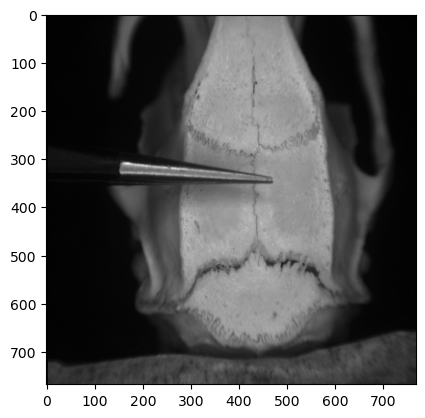

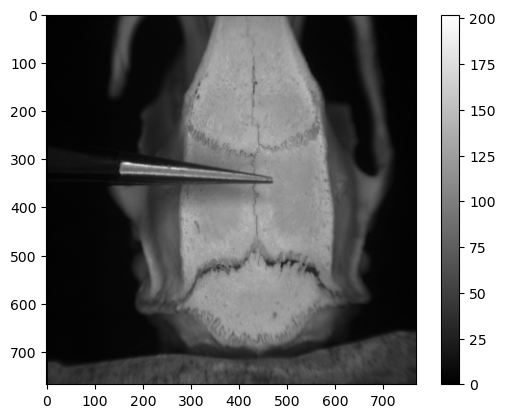

In [10]:
# pick a crop level that shows the desired FOV
print(np.squeeze(dataset.reference_image).shape)
crop = (0, 768, 0, 768) 
full_image = np.squeeze(dataset.reference_image)
crop_image = full_image[crop[0] : crop[1], crop[2] : crop[3]]

plt.imshow(crop_image, cmap = 'gray')

plt.figure()
plt.imshow(full_image, cmap = 'gray')
plt.colorbar()

In [11]:
# determine crop values
shape0 = dataset.images.shape[2]
shape1 = dataset.images.shape[3]

crop_values = (
    crop[0] / shape0,
    crop[1] / shape0,
    crop[2] / shape1,
    crop[3] / shape1,
)
print(crop_values)

(0.0, 1.0, 0.0, 1.0)


In [12]:
dataset = None

# new dataset with the crops
downsample = 1
image_numbers = manager.image_numbers
dataset = FSDataset(
    path_to_data + '/' + image_filename,
    path_to_data + '/' + calibration_filename,
    image_numbers,
    downsample,
    crop_values,
    enforce_divisible=-1,
    frame_number=frame_number,
    blank_filename=bf
)

loading images: 100%|██████████| 48/48 [00:00<00:00, 361.82it/s]


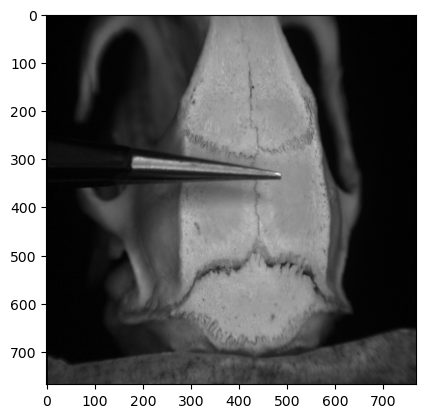

In [13]:
plt.imshow(dataset.images[0].squeeze(), cmap = 'gray')


In [29]:
# find depth extents
low_plane = -20
high_plane = 20

num = 30
depths = np.linspace(low_plane, high_plane, num, endpoint=True)
depth_values = torch.from_numpy(depths).to(torch.float32).cuda()

batch_size = 10
volume = get_ss_volume_from_dataset(dataset, batch_size, depth_values, get_squared=False)
volume = volume.squeeze().cpu().numpy()

In [26]:
print((low_plane, high_plane))

(-25, 25)


In [27]:
depth_values

tensor([-25.0000, -23.2759, -21.5517, -19.8276, -18.1034, -16.3793, -14.6552,
        -12.9310, -11.2069,  -9.4828,  -7.7586,  -6.0345,  -4.3103,  -2.5862,
         -0.8621,   0.8621,   2.5862,   4.3103,   6.0345,   7.7586,   9.4828,
         11.2069,  12.9310,  14.6552,  16.3793,  18.1034,  19.8276,  21.5517,
         23.2759,  25.0000], device='cuda:0')

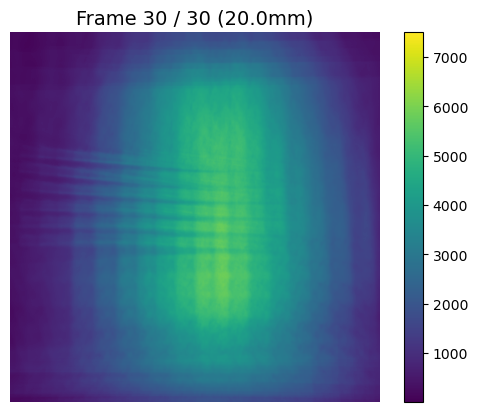

In [31]:
play_video(volume, depth_values, fps=2)

Text(0.5, 1.0, '7.59 mm')

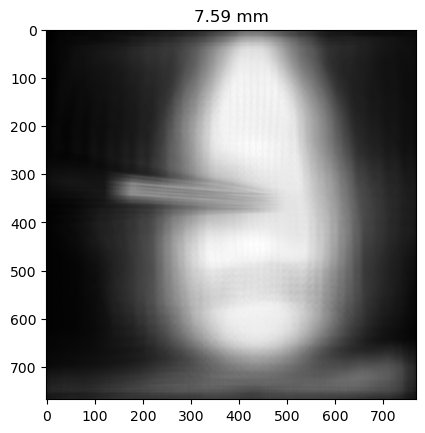

In [34]:
idx = 18
plt.imshow(volume[idx], cmap='gray')
plt.title("{:.2f} mm".format(depths[idx]))

In [ ]:
# make the full sample entry
info = {
    "folder": folder,
    "sample_name": sample_name,
    "calibration_filename": calibration_filename,
    "image_filename": image_filename,
    "crop_values": crop_values,
    "depth_range": (low_plane, high_plane),
    "blank_filename": blank_filename,
}

In [ ]:
# and save it!
# this cell is commented out for the demo

add_sample_entry(sample_name, info, overwrite=False)